# Dask ETL: Distributed Raster Reprojection

Reproject a subset of the USGS 10m seamless DEM from NAD83 geographic coordinates to a projected coordinate system using Dask.

### Overview

This notebook reads elevation data from a 29 TB Zarr store, clips it to a region of interest, and reprojects it from EPSG:4269 (NAD83 lat/lon) to EPSG:5070 (NAD83 / Conus Albers Equal Area). The full dataset is far too large to fit in memory, so every step stays lazy until the final write. The Dask dashboard lets you watch the reprojection work move through the cluster in real time.

Imports

In [13]:
import numpy as np
import xarray as xr
import dask
import dask.array as da
import matplotlib.pyplot as plt
from dask.distributed import Client, LocalCluster
from pathlib import Path

from xrspatial import reproject

## Cluster Setup

In [14]:
cluster = LocalCluster(
    n_workers=10,
    threads_per_worker=1,
    memory_limit="4GB",
)
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 10
Total threads: 10,Total memory: 37.25 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35239,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:32795,Total threads: 1
Dashboard: http://127.0.0.1:42501/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:36759,


2026-03-23 20:02:37,492 - bokeh.server.protocol_handler - ERROR - error handling message
 message: Message 'PATCH-DOC' content: {'events': [{'kind': 'ModelChanged', 'model': {'id': 'p21877'}, 'attr': 'end', 'new': 0.9}]} 
 error: AssertionError()
Traceback (most recent call last):
  File "/home/brendan/miniconda/envs/xarray-spatial-everything/lib/python3.14/site-packages/bokeh/server/protocol_handler.py", line 94, in handle
    work = await handler(message, connection)
                 ~~~~~~~^^^^^^^^^^^^^^^^^^^^^
  File "/home/brendan/miniconda/envs/xarray-spatial-everything/lib/python3.14/site-packages/bokeh/server/session.py", line 295, in patch
    return connection.session._handle_patch(message, connection)
           ^^^^^^^^^^^^^^^^^^
  File "/home/brendan/miniconda/envs/xarray-spatial-everything/lib/python3.14/site-packages/bokeh/server/connection.py", line 65, in session
    assert self._session is not None
           ^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError
2026-03-23 20:02:3

The dashboard is at [http://localhost:8787/status](http://localhost:8787/status) by default. It shows task progress and memory pressure per worker. Adjust `n_workers` and `memory_limit` to match your machine. Four workers at 2 GB each works well on a 16 GB system.

## Extract

The source data is a USGS 10m seamless DEM stored as a chunked Zarr archive. The full extent is roughly 940k by 3.9M pixels at ~10 meter resolution. We'll open it lazily and clip to a smaller region.

In [15]:
ZARR_PATH = Path.home() / "elevation" / "usgs10m_dem_c6.zarr"

ds = xr.open_zarr(ZARR_PATH)
ds

<xarray.Dataset> Size: 29TB
Dimensions:      (y: 939612, x: 3888006)
Coordinates:
  * y            (y) float64 8MB 72.0 72.0 72.0 72.0 ... -15.0 -15.0 -15.0 -15.0
  * x            (x) float64 31MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref  int64 8B ...
Data variables:
    usgs10m_dem  (y, x) float64 29TB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

Nothing has been read from disk yet. The repr above shows the Dask task graph backing the array. Each chunk is 2048 x 2048 pixels.

Let's clip to Colorado. Good mix of flat plains and mountains, and small enough to finish in a reasonable time.

In [16]:
# Bounding box: roughly Colorado plus some margin
lat_min, lat_max = 36.5, 41.5
lon_min, lon_max = -109.5, -101.5

dem = ds["usgs10m_dem"].sel(
    y=slice(lat_max, lat_min),
    x=slice(lon_min, lon_max),
)
dem

<xarray.DataArray 'usgs10m_dem' (y: 54000, x: 86400)> Size: 37GB
dask.array<getitem, shape=(54000, 86400), dtype=float64, chunksize=(2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 432kB 41.5 41.5 41.5 41.5 ... 36.5 36.5 36.5 36.5
  * x            (x) float64 691kB -109.5 -109.5 -109.5 ... -101.5 -101.5 -101.5
    spatial_ref  int64 8B ...
Attributes:
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        4079.3637695312
    STATISTICS_MEAN:           -1.7953889191029e+37
    STATISTICS_MINIMUM:        -3.4028230607371e+38
    STATISTICS_STDDEV:         7.6072653955487e+37
    STATISTICS_VALID_PERCENT:  4.067
    units:                     cm
    original_units:            unknown

In [17]:
print(f"Subset shape: {dem.shape}")
print(f"Subset size:  {dem.nbytes / 1e9:.1f} GB")
print(f"Chunk layout: {dem.chunks}")

Subset shape: (54000, 86400)
Subset size:  37.3 GB
Chunk layout: ((322, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 430), (450, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 2048, 1982))


Even this subset is several GB. The chunked layout means Dask can process it in parallel without loading the whole thing.

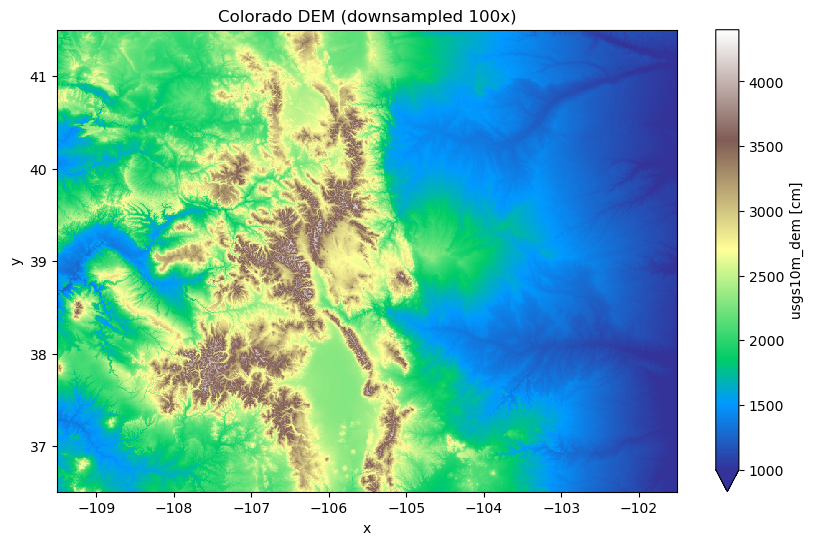

In [18]:
# Quick look at a downsampled slice
stride = 100
preview = dem.isel(y=slice(None, None, stride), x=slice(None, None, stride)).compute()
preview.plot(figsize=(10, 6), cmap="terrain", vmin=1000, vmax=4400)
plt.title("Colorado DEM (downsampled 100x)")
plt.show()

## Transform

The source CRS is EPSG:4269 (NAD83, geographic lat/lon). We'll reproject to EPSG:5070 (NAD83 / Conus Albers Equal Area Conic), which gives equal-area cells in meters. That matters any time pixel area feeds into a calculation, like drainage area or cut/fill volumes, and it makes the DEM compatible with other projected datasets.

`xrspatial.reproject` handles Dask arrays natively. It builds a lazy task graph where each output chunk is reprojected independently using numba-JIT'd resampling kernels.

In [19]:
SOURCE_CRS = "EPSG:4269"
TARGET_CRS = "EPSG:5070"
TARGET_RES = 10  # 10 meter output pixels

dem_projected = reproject(
    dem,
    TARGET_CRS,
    source_crs=SOURCE_CRS,
    resolution=TARGET_RES,
    resampling="nearest",
    nodata=np.nan,
    chunk_size=2048,
)
dem_projected

<xarray.DataArray 'usgs10m_dem' (y: 55780, x: 67461)> Size: 30GB
dask.array<_reproject_block_adapter, shape=(55780, 67461), dtype=float64, chunksize=(2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float64 446kB 2.096e+06 2.096e+06 ... 1.538e+06 1.538e+06
  * x        (x) float64 540kB -1.153e+06 -1.153e+06 ... -4.788e+05 -4.788e+05
Attributes:
    crs:      PROJCRS["NAD83 / Conus Albers",BASEGEOGCRS["NAD83",DATUM["North...
    nodata:   nan

The result is still lazy. The repr shows the projected coordinate arrays and the new shape. No pixels have been resampled yet.

In [20]:
print(f"Output shape: {dem_projected.shape}")
print(f"Output size:  {dem_projected.nbytes / 1e9:.1f} GB")
print(f"Output CRS:   {dem_projected.attrs.get('crs', 'not set')[:60]}...")

Output shape: (55780, 67461)
Output size:  30.1 GB
Output CRS:   PROJCRS["NAD83 / Conus Albers",BASEGEOGCRS["NAD83",DATUM["No...


## Load

Write the reprojected DEM to a new Zarr store. Zarr supports parallel writes natively, so each Dask worker can write its chunks independently. This is where all the actual computation happens.

In [21]:
OUTPUT_PATH = Path("colorado_dem_5070.zarr")

# Package as a Dataset for to_zarr
ds_out = dem_projected.to_dataset(name="elevation")

ds_out.to_zarr(
    OUTPUT_PATH,
    mode="w",
    consolidated=True,
)

/home/brendan/miniconda/envs/xarray-spatial-everything/lib/python3.14/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/home/brendan/miniconda/envs/xarray-spatial-everything/lib/python3.14/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/home/brendan/miniconda/envs/xarray-spatial-everything/lib/python3.14/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-refer

The write triggers the full computation. Watch the dashboard to see tasks moving through the cluster.

In [22]:
# Verify the output
ds_check = xr.open_zarr(OUTPUT_PATH)
print(ds_check)
print(f"\nOutput CRS: {ds_check['elevation'].attrs.get('crs', 'not set')[:60]}...")
print(f"Shape:      {ds_check['elevation'].shape}")
print(f"Size:       {ds_check['elevation'].nbytes / 1e9:.1f} GB")

<xarray.Dataset> Size: 30GB
Dimensions:    (y: 55780, x: 67461)
Coordinates:
  * y          (y) float64 446kB 2.096e+06 2.096e+06 ... 1.538e+06 1.538e+06
  * x          (x) float64 540kB -1.153e+06 -1.153e+06 ... -4.788e+05 -4.788e+05
Data variables:
    elevation  (y, x) float64 30GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

Output CRS: PROJCRS["NAD83 / Conus Albers",BASEGEOGCRS["NAD83",DATUM["No...
Shape:      (55780, 67461)
Size:       30.1 GB


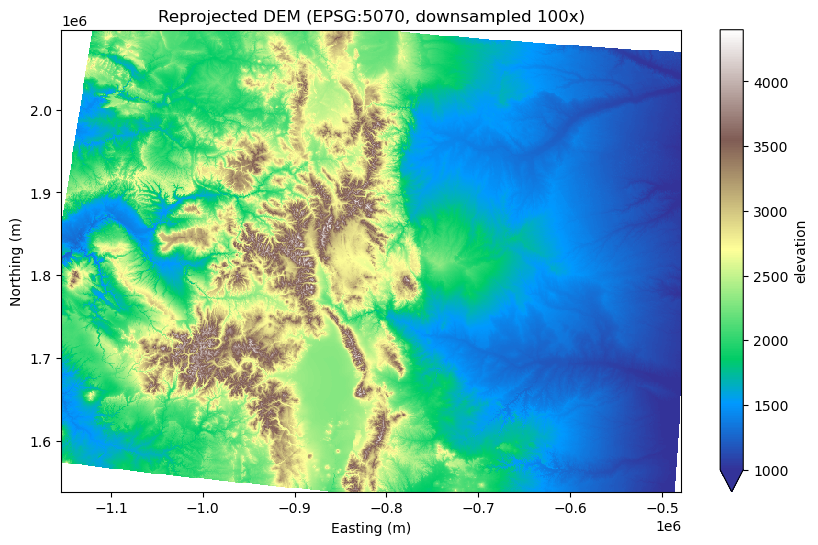

In [23]:
# Visual check on a downsampled slice
stride = 100
check = ds_check["elevation"].isel(
    y=slice(None, None, stride), x=slice(None, None, stride)
).compute()
check.plot(figsize=(10, 6), cmap="terrain", vmin=1000, vmax=4400)
plt.title("Reprojected DEM (EPSG:5070, downsampled 100x)")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.show()

## Cleanup

In [12]:
client.close()
cluster.close()

### What's next

The whole pipeline stayed lazy until the Zarr write, so memory usage stayed within the 2 GB per-worker limit even though the input was several GB.

From here you could:

- Expand the bounding box (or use the full CONUS extent) and add more workers
- Switch to bilinear or cubic resampling (`resampling='bilinear'` or `'cubic'`) for smoother output
- Chain xarray-spatial transforms (slope, hillshade) before the write
- Output to Cloud-Optimized GeoTIFF instead of Zarr if you need HTTP range-request access